In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
df_reg = pd.read_csv("metrics_after_Reg.csv")
df_reg

,data_name,seed,prerank,pce,nll,energy,mse
0,households,0,marginal,0.028741,3.295859,0.951055,0.663382
1,households,42,marginal,0.031749,3.270183,0.882693,0.554523
2,households,866,marginal,0.029671,3.396923,0.965792,0.652964
3,households,12,marginal,0.029982,3.423873,0.960883,0.667672
4,households,4,marginal,0.027437,3.255520,0.935410,0.623558
...,...,...,...,...,...,...,...
660,taxi,0,cdf,0.023317,1.797198,0.687239,0.820930
661,taxi,42,cdf,0.022267,1.818719,0.710010,0.856853
662,taxi,866,cdf,0.020708,1.795314,0.701882,0.824289
663,taxi,12,cdf,0.021154,1.847844,0.704387,0.838678


In [46]:
avg_df = df_reg.groupby(['data_name', 'prerank'], sort=False)[['pce', 'nll', 'energy', 'mse']].mean().reset_index()
avg_df

,data_name,prerank,pce,nll,energy,mse
0,households,marginal,0.029516,3.328471,0.939167,0.632420
1,households,mean,0.023898,3.395145,0.944452,0.628032
2,households,variance,0.021100,3.335899,0.936779,0.634394
3,households,dependency,0.020640,3.228757,0.921436,0.619659
4,households,pca,0.025954,3.330700,0.937192,0.621929
...,...,...,...,...,...,...
128,taxi,variance,0.025400,1.762258,0.706790,0.881143
129,taxi,dependency,0.022659,1.755881,0.700729,0.842394
130,taxi,pca,0.022237,1.805602,0.706540,0.857116
131,taxi,density,0.022224,1.741710,0.698352,0.832212


In [88]:
avg_df = df_reg.groupby(['data_name', 'prerank'], sort=False)[['pce', 'nll', 'energy', 'mse']].mean().reset_index()
avg_df = avg_df[~avg_df['data_name'].isin(['rf1', 'rf2', 'sf2'])]
avg_df.shape

(126, 6)

In [89]:
avg_df

,data_name,prerank,pce,nll,energy,mse
0,households,marginal,0.029516,3.328471,0.939167,0.632420
1,households,mean,0.023898,3.395145,0.944452,0.628032
2,households,variance,0.021100,3.335899,0.936779,0.634394
3,households,dependency,0.020640,3.228757,0.921436,0.619659
4,households,pca,0.025954,3.330700,0.937192,0.621929
...,...,...,...,...,...,...
128,taxi,variance,0.025400,1.762258,0.706790,0.881143
129,taxi,dependency,0.022659,1.755881,0.700729,0.842394
130,taxi,pca,0.022237,1.805602,0.706540,0.857116
131,taxi,density,0.022224,1.741710,0.698352,0.832212


In [62]:
df_without = pd.read_csv("metrics_before_reg.csv")
df_without

,data_name,seed,prerank,pce,nll,energy,mse
0,households,0,marginal,0.089804,3.234141,0.933722,0.648897
1,households,0,mean,0.089603,3.234141,0.932309,0.648897
2,households,0,variance,0.145472,3.234141,0.932362,0.648897
3,households,0,dependency,0.016523,3.234141,0.937315,0.648897
4,households,0,pca,0.066246,3.234141,0.934260,0.648897
...,...,...,...,...,...,...,...
730,taxi,4,variance,0.097945,1.710399,0.693529,0.821596
731,taxi,4,dependency,0.100943,1.710399,0.694324,0.821596
732,taxi,4,pca,0.097408,1.710399,0.692537,0.821596
733,taxi,4,density,0.040966,1.710399,0.693831,0.821596


In [90]:
avg_df_without = df_without.groupby(['data_name', 'prerank'], sort=False)[['pce', 'nll', 'energy', 'mse']].mean().reset_index()
avg_df_without

,data_name,prerank,pce,nll,energy,mse
0,households,marginal,0.094671,3.187087,0.917795,0.614488
1,households,mean,0.091937,3.187087,0.917843,0.614488
2,households,variance,0.125329,3.187087,0.919684,0.614488
3,households,dependency,0.021782,3.187087,0.919045,0.614488
4,households,pca,0.066102,3.187087,0.918087,0.614488
...,...,...,...,...,...,...
142,taxi,variance,0.093558,1.693866,0.690725,0.816411
143,taxi,dependency,0.095963,1.693866,0.690676,0.816411
144,taxi,pca,0.093891,1.693866,0.690356,0.816411
145,taxi,density,0.041648,1.693866,0.690504,0.816411


In [109]:
avg_scores_per_data = avg_df_without.groupby('data_name', sort=False)[['pce', 'nll', 'energy', 'mse']].mean().reset_index()
avg_scores_per_data['prerank'] = 'none'
# avg_scores_per_data['pce'] = 0
avg_scores_per_data.head()

,data_name,pce,nll,energy,mse,prerank
0,households,0.092344,3.187087,0.918165,0.614488,none
1,air,0.109490,5.650568,1.397655,0.937892,none
2,births1,0.106116,1.181293,0.682644,0.759425,none
3,births2,0.161064,-4.447253,0.922516,1.067480,none
4,wage,0.154958,0.511141,0.711580,0.727497,none


In [110]:
# Define custom order: "none" first, then the rest (sorted or explicitly ordered)
prerank_order = ['none', 'marginal', 'mean', 'variance', 'dependency', 'pca', 'density', 'cdf']

# Concat the two DataFrames
combined = pd.concat([avg_df, avg_scores_per_data], ignore_index=True)

# Convert 'prerank' column to categorical with desired order
combined['prerank'] = pd.Categorical(combined['prerank'], categories=prerank_order, ordered=True)

# Sort by dataset and then prerank
combined = combined.sort_values(['data_name', 'prerank']).reset_index(drop=True)
combined.head(8)

,data_name,prerank,pce,nll,energy,mse
0,air,none,0.109490,5.650568,1.397655,0.937892
1,air,marginal,0.039892,5.798495,1.421109,0.950752
2,air,mean,0.026328,5.812055,1.427127,0.949652
3,air,variance,0.026756,5.750404,1.417962,0.956134
4,air,dependency,0.026949,5.712583,1.405788,0.948559
5,air,pca,0.039238,5.787327,1.416858,0.944779
6,air,density,0.044818,5.666744,1.405010,0.942634
7,air,cdf,0.029004,5.798847,1.435200,0.993631


In [111]:
plt.rcParams.update({'font.size': 10})
import matplotlib.patches as mpatches

# Step 1: get only 'density' rows
density_df = combined[combined['prerank'] == 'density']

# Step 2: find top 4 datasets with highest PCE
top4 = density_df.nlargest(4, 'pce')['data_name']

# Step 3: remove those datasets entirely (all their preranks)
filtered_df_ours = combined[~combined['data_name'].isin(top4)]

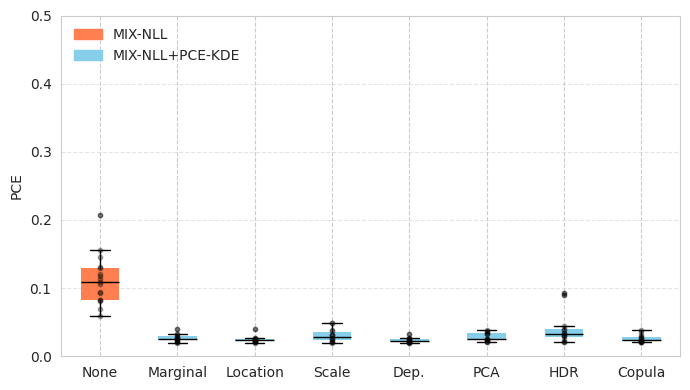

In [112]:
preranks = filtered_df_ours['prerank'].unique()

data = [filtered_df_ours[filtered_df_ours['prerank'] == p]['pce'].values
        for p in preranks]

plt.figure(figsize=(7, 4))

labels = ["None", "Marginal", "Location", "Scale", "Dep.", "PCA", "HDR", "Copula"]

flierprops = dict(marker='o', markerfacecolor='black', markeredgecolor='black', markersize=3, linestyle='none', alpha=0.3) #outliers

box = plt.boxplot(data, tick_labels=labels, patch_artist=True, zorder = 2,
                  flierprops=flierprops, meanline = True, boxprops=dict(color='none'))

for i, patch in enumerate(box['boxes']):
    if i==0:
        patch.set_facecolor("coral")
    else:
        patch.set_facecolor("skyblue")


    # patch.set_edgecolor("#9673A6")
#color for NLL (opaque red) --> (227/255, 119/255, 119/255, 0.3)
#colors for Energy (opaque green) --> (44/255, 160/255, 44/255, 0.3)
#colors for PCE (opaque blue) --> (31/255, 119/255, 180/255, 0.7)
# for whisker in box['whiskers']:
#     whisker.set_color('#9673A6')
#     whisker.set_linewidth(1.5)

# for cap in box['caps']:
#     cap.set_color('#9673A6')
#     cap.set_linewidth(1.5)

for median in box['medians']:
    median.set_linewidth(1)
    median.set_color("black")
# box['medians'][-1].set_color("#1a9012")
for i, p in enumerate(data):
    x = [i + 1] * len(p)
    plt.scatter(x, p, color='black', s=10, zorder=3, alpha = 0.3)

orange_patch = mpatches.Patch(color="coral", label='MIX-NLL')
green_patch = mpatches.Patch(color="skyblue", label='MIX-NLL+PCE-KDE')

plt.ylim(0, 0.50)

plt.ylabel("PCE")
plt.tight_layout()
plt.legend(handles=[orange_patch, green_patch], loc='upper left', frameon=False)
# plt.gca().set_axisbelow(False)
plt.grid(axis='y', linestyle='--', alpha=0.5, zorder=4)
plt.savefig(f"box_plot_before_after_pce.png", bbox_inches='tight', dpi=500)
plt.show()

In [ ]:
avg_df_without = df_without.groupby(['data_name', 'prerank'], sort=False)[['pce', 'nll', 'energy', 'mse']].mean().reset_index()
avg_df_without

,data_name,prerank,pce,nll,energy,mse
0,households,marginal,0.094671,3.187087,0.917795,0.614488
1,households,mean,0.091937,3.187087,0.917843,0.614488
2,households,variance,0.125329,3.187087,0.919684,0.614488
3,households,dependency,0.021782,3.187087,0.919045,0.614488
4,households,pca,0.066102,3.187087,0.918087,0.614488
...,...,...,...,...,...,...
142,taxi,variance,0.093558,1.693866,0.690725,0.816411
143,taxi,dependency,0.095963,1.693866,0.690676,0.816411
144,taxi,pca,0.093891,1.693866,0.690356,0.816411
145,taxi,density,0.041648,1.693866,0.690504,0.816411


In [85]:
# avg_without = df_without.groupby(['data_name'], sort=False)[[ 'nll', 'energy', 'pce_marginal', 'pce_mean',
#        'pce_variance', 'pce_dependency', 'pce_pca', 'pce_density', 'pce_cdf',
#        'mse']].mean().reset_index()
# avg_without

In [86]:
# pce_cols = [c for c in avg_without.columns if c.startswith('pce_')]


# baseline_melted = avg_df_without.melt(
#     id_vars=['data_name'],
#     value_vars='pce',
#     var_name='prerank_type',
#     value_name='pce_baseline'
# )

# baseline_melted

In [ ]:
# baseline_melted['prerank'] = baseline_melted['prerank_type'].str.replace('pce_', '')

In [87]:
avg_df_without['pce_baseline'] = avg_df_without['pce']

In [82]:
comparison_df = pd.merge(
    avg_df[['data_name', 'prerank', 'pce']],
    avg_df_without[['data_name', 'prerank', 'pce_baseline']],
    on=['data_name', 'prerank']
)
comparison_df

,data_name,prerank,pce,pce_baseline
0,households,marginal,0.029516,0.094671
1,households,mean,0.023898,0.091937
2,households,variance,0.021100,0.125329
3,households,dependency,0.020640,0.021782
4,households,pca,0.025954,0.066102
...,...,...,...,...
128,taxi,variance,0.025400,0.093558
129,taxi,dependency,0.022659,0.095963
130,taxi,pca,0.022237,0.093891
131,taxi,density,0.022224,0.041648


In [83]:
comparison_df = comparison_df.rename(columns={'pce': 'pce_regularized'})
comparison_df['reduction_%'] = (
    (comparison_df['pce_baseline'] - comparison_df['pce_regularized'])
    / comparison_df['pce_baseline'] * 100
)
# Sort for better visibility
comparison_df = comparison_df.sort_values(['data_name', 'prerank']).reset_index(drop=True)
comparison_df

,data_name,prerank,pce_regularized,pce_baseline,reduction_%
0,air,cdf,0.029004,0.158003,81.643037
1,air,density,0.044818,0.080985,44.658122
2,air,dependency,0.026949,0.060174,55.215098
3,air,marginal,0.039892,0.099014,59.711419
4,air,mean,0.026328,0.092714,71.603561
...,...,...,...,...,...
128,wq,dependency,0.027509,0.035596,22.718839
129,wq,marginal,0.154111,0.166750,7.579957
130,wq,mean,0.075698,0.104432,27.514387
131,wq,pca,0.090574,0.093138,2.753284


In [ ]:
# comparison_df = pd.merge(
#     avg_df[['data_name', 'prerank', 'pce']],
#     baseline_melted[['data_name', 'prerank', 'pce_baseline']],
#     on=['data_name', 'prerank']
# )
# comparison_df = comparison_df.rename(columns={'pce': 'pce_regularized'})
# comparison_df['reduction_%'] = (
#     (comparison_df['pce_baseline'] - comparison_df['pce_regularized'])
#     / comparison_df['pce_baseline'] * 100
# )
# # Sort for better visibility
# comparison_df = comparison_df.sort_values(['data_name', 'prerank']).reset_index(drop=True)
# comparison_df

,data_name,prerank,pce_regularized,pce_baseline,reduction_%


In [ ]:
prerank_order = ['marginal', 'mean', 'variance', 'dependency', 'pca', 'density', 'cdf']
label_map = {
    'marginal': 'Marginal',
    'mean': 'Location',
    'variance': 'Scale',
    'dependency': 'Dep.',
    'pca': 'PCA',
    'density': 'HDR',
    'cdf': 'Copula'
}

plot_reg = df_reg[df_reg['prerank'].isin(prerank_order)].copy()
plot_reg['Model'] = 'MIX-NLL+PCE-KDE'
plot_reg['Category'] = plot_reg['prerank'].map(label_map)

baseline_list = []
for pr in prerank_order:
    temp = df_without[['data_name', 'seed', f'pce_{pr}']].copy()
    temp = temp.rename(columns={f'pce_{pr}': 'pce'})
    temp['Category'] = label_map[pr]
    temp['Model'] = 'MIX-NLL'
    baseline_list.append(temp)
plot_baseline = pd.concat(baseline_list)


plot_df = pd.concat([
    plot_baseline[['Category', 'pce', 'Model']],
    plot_reg[['Category', 'pce', 'Model']]
])


plt.figure(figsize=(13, 6))
sns.set_style("whitegrid", {'grid.linestyle': '--'})


colors = {"MIX-NLL": "tab:orange", "MIX-NLL+PCE-KDE": "skyblue"}

ax = sns.boxplot(
    data=plot_df,
    x='Category',
    y='pce',
    hue='Model',
    order=[label_map[p] for p in prerank_order],
    palette=colors,
    showfliers=False,  # Outliers handled by stripplot
    width=0.6,
    linewidth=1.5
)

sns.stripplot(
    data=plot_df,
    x='Category',
    y='pce',
    hue='Model',
    order=[label_map[p] for p in prerank_order],
    palette=colors,
    dodge=True,
    alpha=0.4,
    size=3,
    jitter=0.2,
    ax=ax
)

plt.xlabel("")
plt.ylabel("PCE", fontsize=15)
plt.title("(a) PCE", fontsize=18, y=-0.2)

handles, labels = ax.get_legend_handles_labels()
plt.legend(handles[0:2], labels[0:2], loc='upper left', frameon=False, fontsize=15)

plt.ylim(0, 0.45)

sns.despine()
plt.tight_layout()
plt.show()

KeyError: "['pce_marginal'] not in index"

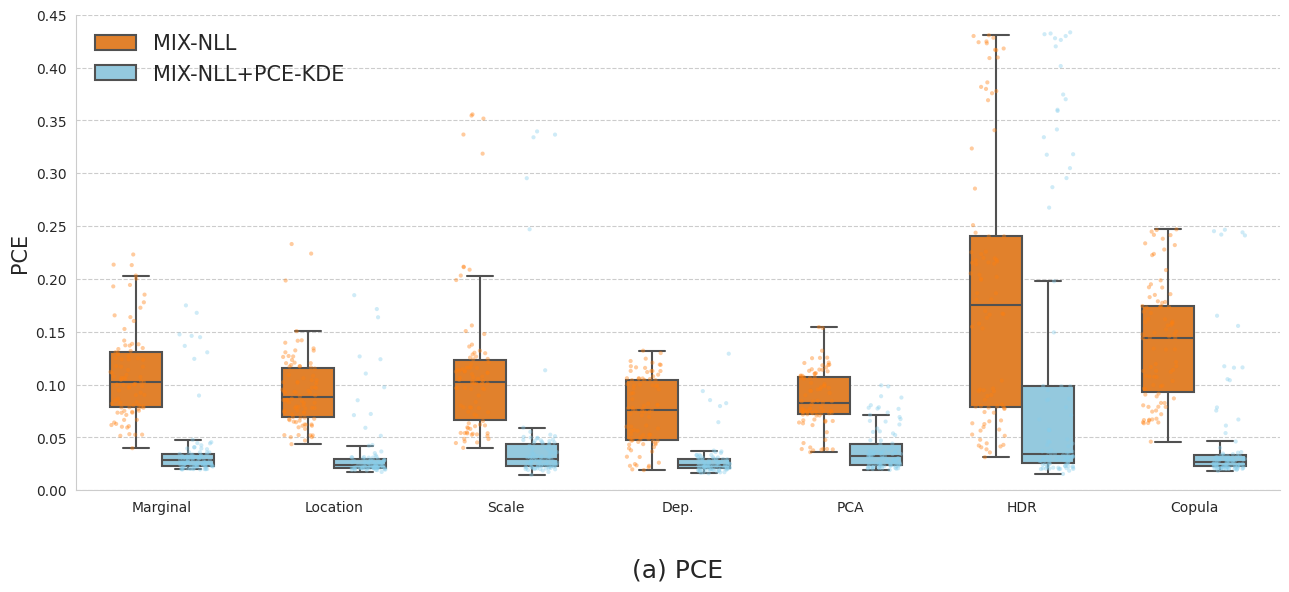

In [52]:
prerank_order = ['marginal', 'mean', 'variance', 'dependency', 'pca', 'density', 'cdf']
label_map = {
    'marginal': 'Marginal',
    'mean': 'Location',
    'variance': 'Scale',
    'dependency': 'Dep.',
    'pca': 'PCA',
    'density': 'HDR',
    'cdf': 'Copula'
}

plot_reg = df_reg[df_reg['prerank'].isin(prerank_order)].copy()
plot_reg['Model'] = 'MIX-NLL+PCE-KDE'
plot_reg['Category'] = plot_reg['prerank'].map(label_map)

baseline_list = []
for pr in prerank_order:
    temp = df_without[['data_name', 'seed', f'pce_{pr}']].copy()
    temp = temp.rename(columns={f'pce_{pr}': 'pce'})
    temp['Category'] = label_map[pr]
    temp['Model'] = 'MIX-NLL'
    baseline_list.append(temp)
plot_baseline = pd.concat(baseline_list)


plot_df = pd.concat([
    plot_baseline[['Category', 'pce', 'Model']],
    plot_reg[['Category', 'pce', 'Model']]
])


plt.figure(figsize=(13, 6))
sns.set_style("whitegrid", {'grid.linestyle': '--'})


colors = {"MIX-NLL": "tab:orange", "MIX-NLL+PCE-KDE": "skyblue"}

ax = sns.boxplot(
    data=plot_df,
    x='Category',
    y='pce',
    hue='Model',
    order=[label_map[p] for p in prerank_order],
    palette=colors,
    showfliers=False,  # Outliers handled by stripplot
    width=0.6,
    linewidth=1.5
)

sns.stripplot(
    data=plot_df,
    x='Category',
    y='pce',
    hue='Model',
    order=[label_map[p] for p in prerank_order],
    palette=colors,
    dodge=True,
    alpha=0.4,
    size=3,
    jitter=0.2,
    ax=ax
)

plt.xlabel("")
plt.ylabel("PCE", fontsize=15)
plt.title("(a) PCE", fontsize=18, y=-0.2)

handles, labels = ax.get_legend_handles_labels()
plt.legend(handles[0:2], labels[0:2], loc='upper left', frameon=False, fontsize=15)

plt.ylim(0, 0.45)

sns.despine()
plt.tight_layout()
plt.show()

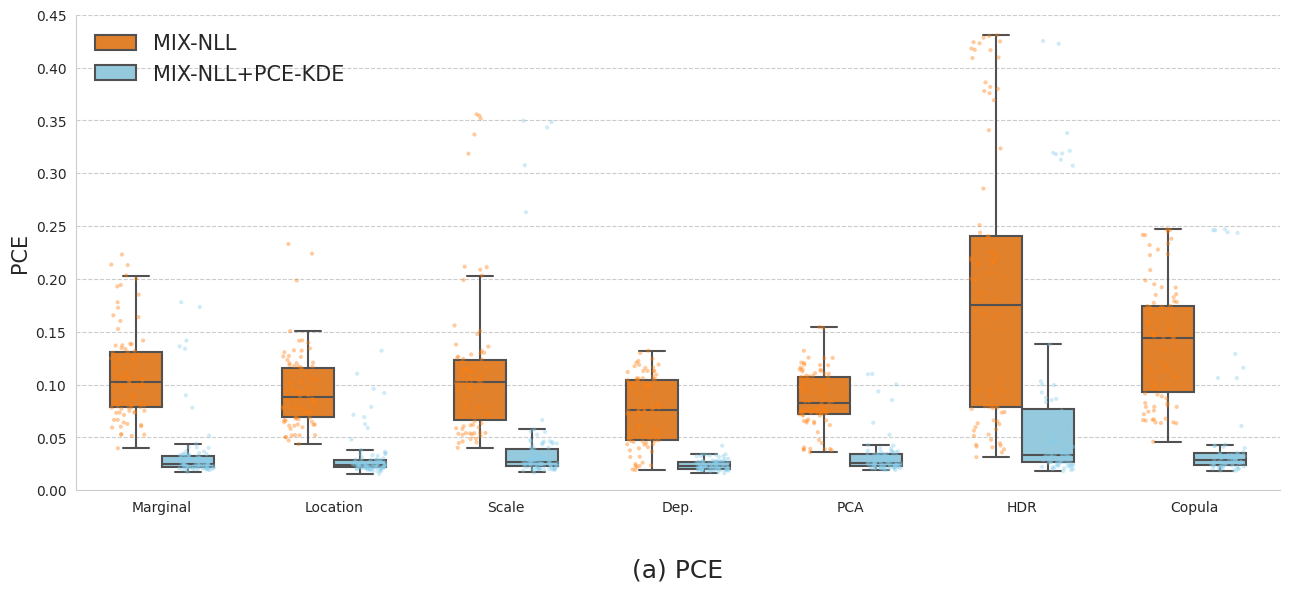

In [18]:
prerank_order = ['marginal', 'mean', 'variance', 'dependency', 'pca', 'density', 'cdf']
label_map = {
    'marginal': 'Marginal',
    'mean': 'Location',
    'variance': 'Scale',
    'dependency': 'Dep.',
    'pca': 'PCA',
    'density': 'HDR',
    'cdf': 'Copula'
}

plot_reg = df_reg[df_reg['prerank'].isin(prerank_order)].copy()
plot_reg['Model'] = 'MIX-NLL+PCE-KDE'
plot_reg['Category'] = plot_reg['prerank'].map(label_map)

baseline_list = []
for pr in prerank_order:
    temp = df_without[['data_name', 'seed', f'pce_{pr}']].copy()
    temp = temp.rename(columns={f'pce_{pr}': 'pce'})
    temp['Category'] = label_map[pr]
    temp['Model'] = 'MIX-NLL'
    baseline_list.append(temp)
plot_baseline = pd.concat(baseline_list)


plot_df = pd.concat([
    plot_baseline[['Category', 'pce', 'Model']],
    plot_reg[['Category', 'pce', 'Model']]
])


plt.figure(figsize=(13, 6))
sns.set_style("whitegrid", {'grid.linestyle': '--'})


colors = {"MIX-NLL": "tab:orange", "MIX-NLL+PCE-KDE": "skyblue"}

ax = sns.boxplot(
    data=plot_df,
    x='Category',
    y='pce',
    hue='Model',
    order=[label_map[p] for p in prerank_order],
    palette=colors,
    showfliers=False,  # Outliers handled by stripplot
    width=0.6,
    linewidth=1.5
)

sns.stripplot(
    data=plot_df,
    x='Category',
    y='pce',
    hue='Model',
    order=[label_map[p] for p in prerank_order],
    palette=colors,
    dodge=True,
    alpha=0.4,
    size=3,
    jitter=0.2,
    ax=ax
)

plt.xlabel("")
plt.ylabel("PCE", fontsize=15)
plt.title("(a) PCE", fontsize=18, y=-0.2)

handles, labels = ax.get_legend_handles_labels()
plt.legend(handles[0:2], labels[0:2], loc='upper left', frameon=False, fontsize=15)

plt.ylim(0, 0.45)

sns.despine()
plt.tight_layout()
plt.show()

In [55]:
plot_none = df_without[['nll', 'energy']].copy()
plot_none['Category'] = 'None'
plot_none['Model'] = 'MIX-NLL'

plot_reg = df_reg[['prerank', 'nll', 'energy']].copy()
plot_reg['Category'] = plot_reg['prerank'].map(label_map)
plot_reg['Model'] = 'MIX-NLL+PCE-KDE'

full_plot_df = pd.concat([plot_none, plot_reg])
plot_order = ['None'] + [label_map[p] for p in prerank_order]


colors = {"MIX-NLL": "tab:orange", "MIX-NLL+PCE-KDE": "skyblue"}

def create_comparison_plot(metric_name, label_text, title_label):
    plt.figure(figsize=(10, 5))
    sns.set_style("whitegrid", {'grid.linestyle': '--'})

    ax = sns.boxplot(
        data=full_plot_df, x='Category', y=metric_name, hue='Model',
        order=plot_order, palette=colors, dodge=False, showfliers=False, width=0.6,linewidth=1.5
    )

    sns.stripplot(
        data=full_plot_df, x='Category', y=metric_name, hue='Model',
        order=plot_order, palette=colors, dodge=False, alpha=0.5, size=4, jitter=0.2, ax=ax
    )

    plt.xlabel("")
    plt.ylabel(label_text, fontsize=12)
    plt.title(title_label, fontsize=16, y=-0.25)
    ax.get_legend().remove()
    sns.despine()

    y_max = full_plot_df[metric_name].quantile(0.95) * 1.2
    y_min = full_plot_df[metric_name].min() * 0.95
    plt.ylim(y_min-0.5, y_max)

    plt.tight_layout()
    plt.show()

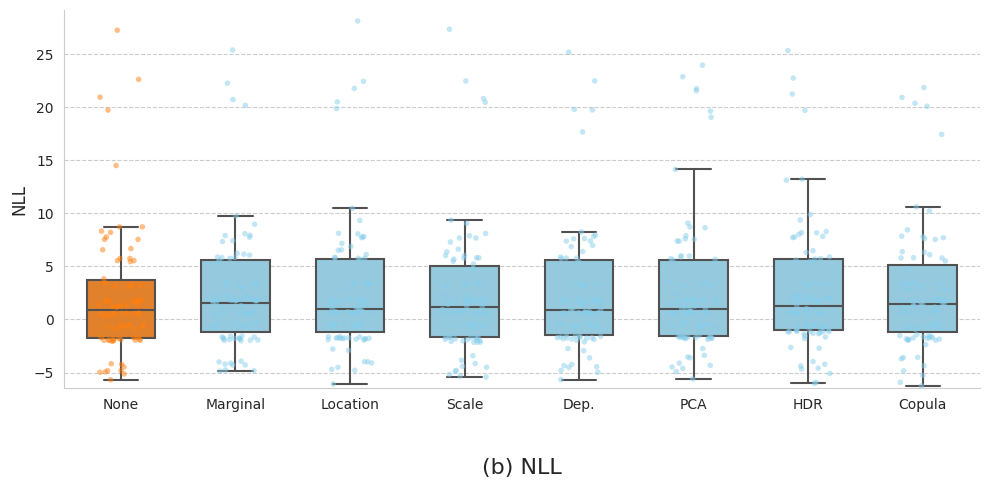

In [56]:
create_comparison_plot('nll', 'NLL', '(b) NLL')

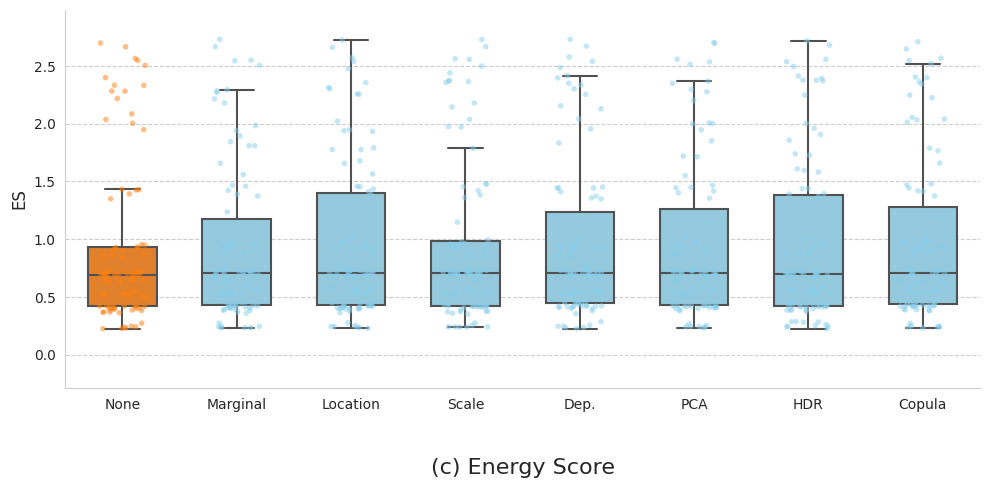

In [58]:
create_comparison_plot('energy', 'ES', '(c) Energy Score')

In [59]:
plot_none = df_without[['nll', 'energy']].copy()
plot_none['Category'] = 'None'
plot_none['Model'] = 'MIX-NLL'

plot_reg = df_reg[['prerank', 'nll', 'energy']].copy()
plot_reg['Category'] = plot_reg['prerank'].map(label_map)
plot_reg['Model'] = 'MIX-NLL+PCE-KDE'

full_plot_df = pd.concat([plot_none, plot_reg])
plot_order = ['None'] + [label_map[p] for p in prerank_order]

ValueError: Dimensions of labels and X must be compatible

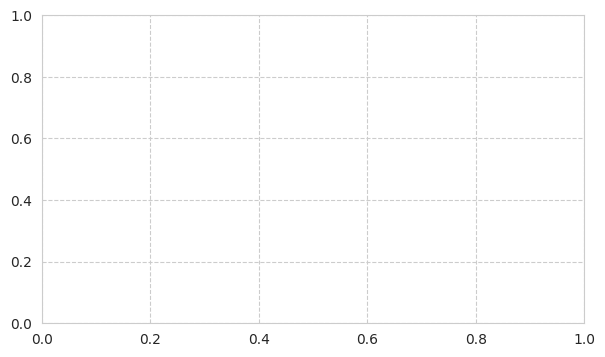

In [ ]:
preranks = df_reg['prerank'].unique()

data = [df_reg[df_reg['prerank'] == p]['nll'].values
        for p in preranks]

plt.figure(figsize=(7, 4))

labels = ["None", "Marginal", "Location", "Scale", "Dep.", "PCA", "HDR", "Copula"]

flierprops = dict(marker='o', markerfacecolor='black', markeredgecolor='black', markersize=3, linestyle='none', alpha=0.3) #outliers


    # ax = sns.boxplot(
    #     data=full_plot_df, x='Category', y=metric_name, hue='Model',
    #     order=plot_order, palette=colors, dodge=False, showfliers=False, width=0.6,linewidth=1.5
    # )


box = plt.boxplot(full_plot_df, tick_labels='Category', patch_artist=True, zorder = 2,
                  flierprops=flierprops, meanline = True, boxprops=dict(color='none'))

for i, patch in enumerate(box['boxes']):
    if i==0:
        patch.set_facecolor("coral")
    else:
        patch.set_facecolor("skyblue")

    # patch.set_edgecolor("#9673A6")
#color for NLL (opaque red) --> (227/255, 119/255, 119/255, 0.3)
#colors for Energy (opaque green) --> (44/255, 160/255, 44/255, 0.3)
#colors for PCE (opaque blue) --> (31/255, 119/255, 180/255, 0.7)
# for whisker in box['whiskers']:
#     whisker.set_color('#9673A6')
#     whisker.set_linewidth(1.5)

# for cap in box['caps']:
#     cap.set_color('#9673A6')
#     cap.set_linewidth(1.5)

for median in box['medians']:
    median.set_linewidth(1)
    median.set_color("black")
# box['medians'][-1].set_color("#1a9012")
for i, p in enumerate(data):
    x = [i + 1] * len(p)
    plt.scatter(x, p, color='black', s=10, zorder=3, alpha = 0.3)

orange_patch = mpatches.Patch(color="coral", label='MIX-NLL')
green_patch = mpatches.Patch(color="skyblue", label='MIX-NLL+PCE-KDE')

plt.ylabel("MSE")
plt.tight_layout()
plt.legend(handles=[orange_patch, green_patch], loc='upper left', frameon=False)
plt.gca().set_axisbelow(False)
plt.grid(axis='y', linestyle='--', alpha=0.5, zorder=4)
# plt.savefig(f"figures/paper/box_plot_before_after_mse.png", bbox_inches='tight', dpi=500)
plt.show()